
# Data Assimilation Demo — Sine Signal (Nudging, KF, EnKF)

This notebook reproduces the simplified data assimilation example you provided, using a **sine signal** as truth and comparing:
- **Nudging**
- **Kalman Filter (KF)**
- **Ensemble Kalman Filter (EnKF)**

All methods share the same time grid, truth, sparse observations, and a biased model forecast. Plots are saved as PNGs alongside being shown inline.


In [9]:
# === Libraries and plotting configuration ===
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import mean_squared_error
from scipy.optimize import minimize

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 20,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    # Do not use font.weight here: it has no effect when using LaTeX
})

np.random.seed(42)


In [10]:

# --- Simulation parameters ---
t = np.linspace(0, 20, 200)
dt = t[1] - t[0]
true_signal = np.sin(np.pi * t / 10)

# Observations (sparse)
obs_indices = np.arange(0, 150, 40)
obs_indices = np.append(obs_indices, [50, 140])
obs_indices = np.unique(obs_indices)

sigma_obs = 0.1
observations = true_signal[obs_indices] + np.random.normal(0, sigma_obs, len(obs_indices))
obs_dict = dict(zip(obs_indices, observations))

# Baseline forecast (biased)
forecast = np.zeros_like(t)
forecast[0] = -0.5
for i in range(1, len(t)):
    forecast[i] = forecast[i-1] + dt * np.cos(np.pi * t[i-1] / 10)


In [11]:

# --- Error parameters ---
R = sigma_obs**2     # observation variance
B = 0.5              # (used here as a simple scalar prior variance for gains)
H = 1.0              # direct observation of the state

# --- Initial copies for each method ---
# Nudging
nudging = np.copy(forecast)
nudging_gain = 0.2

# Kalman Filter (scalar gain for this 1D state)
kalman = np.copy(forecast)
kalman_gain = B * H / (H * B * H + R)  # constant in this simple setup

# Ensemble Kalman Filter (stochastic EnKF)
n_ensemble = 20
ensemble = np.zeros((n_ensemble, len(t)))
ensemble[:, 0] = -0.5 + np.random.normal(0, np.sqrt(B), size=n_ensemble)
enkf_gain = B * H / (H * B * H + R)    # constant gain for this simple EnKF
enkf_mean = np.zeros_like(t)
enkf_mean[0] = ensemble[:, 0].mean()


In [12]:

# --- Assimilation loop ---
for i in range(1, len(t)):
    model_derivative = np.cos(np.pi * t[i-1] / 10)
    
    # Forecast model step (baseline)
    forecast[i] = forecast[i-1] + dt * model_derivative

    # Nudging
    nudging[i] = nudging[i-1] + dt * model_derivative
    if i in obs_indices:
        nudging[i] += nudging_gain * (obs_dict[i] - nudging[i])

    # Kalman Filter (scalar, constant gain)
    kalman[i] = kalman[i-1] + dt * model_derivative
    if i in obs_indices:
        kalman[i] += kalman_gain * (obs_dict[i] - kalman[i])

    # Ensemble Kalman Filter (stochastic, perturbed obs)
    for n in range(n_ensemble):
        ensemble[n, i] = ensemble[n, i-1] + dt * model_derivative
        if i in obs_indices:
            perturbed_obs = obs_dict[i] + np.random.normal(0, sigma_obs)
            ensemble[n, i] += enkf_gain * (perturbed_obs - ensemble[n, i])
    enkf_mean[i] = ensemble[:, i].mean()


In [25]:

# --- Plot helper ---
def plot_method(title, method_series, color, show_ensemble=False):
    plt.figure(figsize=(8, 5))
    plt.plot(t, true_signal, label="True", color="black", linewidth=2)
    plt.plot(t, forecast, linestyle="--", label="Forecast", color="blue")
    plt.plot(t[obs_indices], observations, 'o', label="Observations", color="gray", markersize=6)

    if show_ensemble:
        for n in range(n_ensemble):
            plt.plot(t, ensemble[n], color="gray", linewidth=1, alpha=0.6)

    plt.plot(t, method_series, label=title, linewidth=2, color=color)
    plt.title(title, fontsize=18)
    plt.xlabel("Time", fontsize=16)
    plt.ylabel("State", fontsize=16)
    plt.grid(True)
    plt.legend()
    plt.xlim(0, 20)
    plt.ylim(-4, 5)
    plt.tight_layout()
    plt.show()



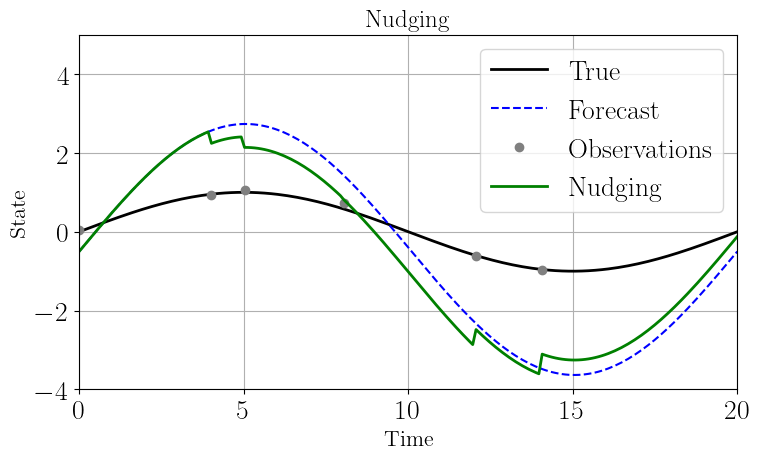

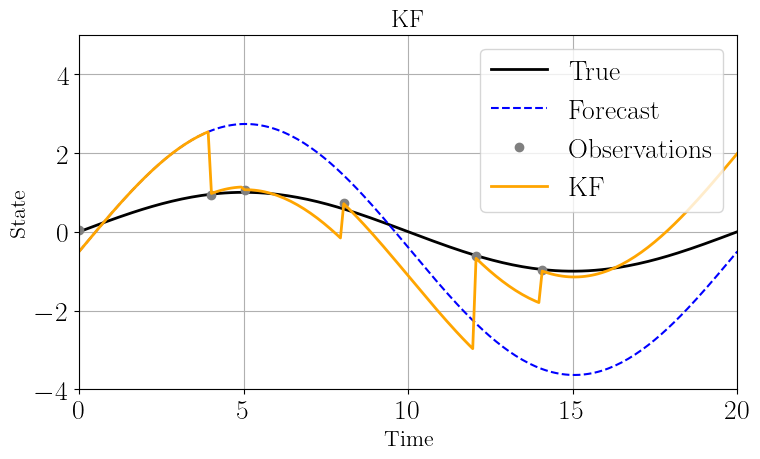

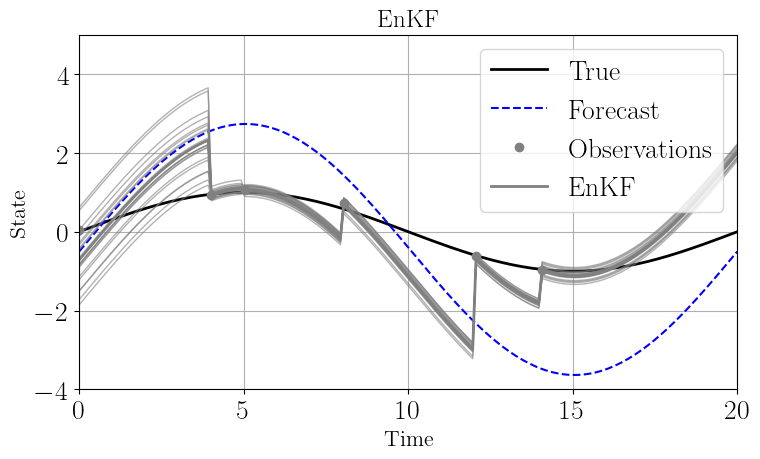

In [27]:

# --- Render individual figures ---
plot_method("Nudging", nudging, color="green")
plot_method("KF", kalman, color="orange")
plot_method("EnKF", enkf_mean, color="grey", show_ensemble=True)


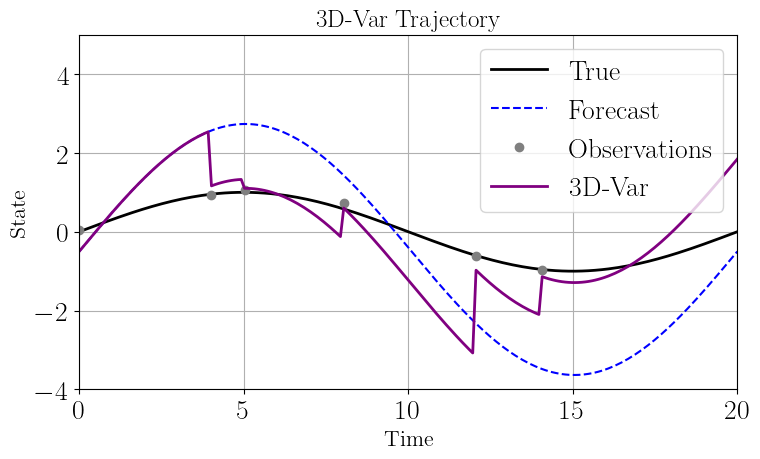

In [16]:
# === 3D-Var (sequential, constant gain; uses shared t, dt, obs_dict, forecast) ===

# Observation/operator and covariances (scalars in this 1D example)
H = 1.0                 # direct observation of the state
sigma_obs = 0.10        # observation std (match your obs noise)
R = sigma_obs**2        # observation variance
sigma_b = 0.25          # background std
B = sigma_b**2          # background variance

# Constant 3D-Var gain (scalar)
K_const = B * H / (H * B * H + R)

# Model step (same model as the notebook)
def model_step(x_prev, t_prev, dt):
    # x_k = x_{k-1} + dt * cos(pi * t_{k-1} / 10)
    return x_prev + dt * np.cos(np.pi * t_prev / 10)

# Pure forecast is already computed in `forecast`
# Build 3D-Var analysis trajectory
x3dvar = np.zeros_like(t)
x3dvar[0] = forecast[0]  # background at initial time

for k in range(1, len(t)):
    # 1) forecast from previous analysis
    x_f = model_step(x3dvar[k-1], t[k-1], dt)

    # 2) if there is an observation at k: analysis = forecast + K*(y - Hx_f)
    if k in obs_dict:
        yk = obs_dict[k]
        innov = yk - H * x_f
        x_a = x_f + K_const * innov
    else:
        x_a = x_f

    x3dvar[k] = x_a

# Plot
plt.figure(figsize=(8, 5))
plt.plot(t, true_signal, label="True", color="black", linewidth=2)
plt.plot(t, forecast, label="Forecast", linestyle="--", color="blue")
plt.plot(t[obs_indices], observations, 'o', label="Observations", color="gray", markersize=6)
plt.plot(t, x3dvar, label="3D-Var", color="purple", linewidth=2)
plt.title("3D-Var Trajectory", fontsize=18)
plt.xlabel("Time", fontsize=16)
plt.ylabel("State", fontsize=16)
plt.grid(True); plt.legend(); plt.xlim(0, 20); plt.ylim(-4, 5)
plt.tight_layout(); plt.show()


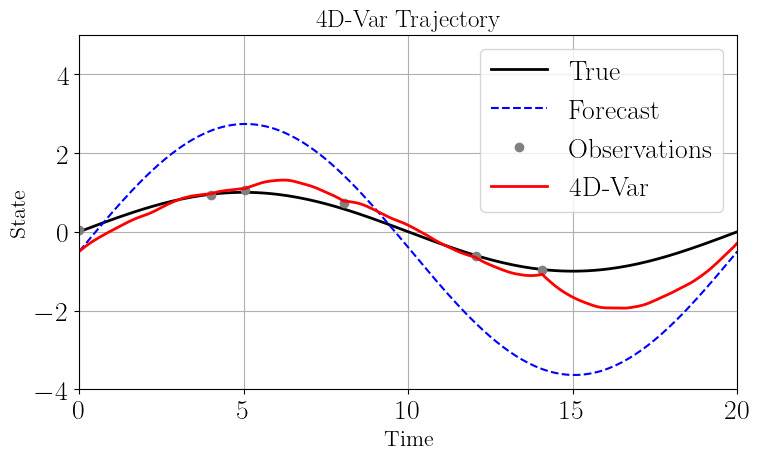

In [17]:
# === 4D-Var (weak-constraint, windowed; uses shared t, dt, obs_dict, forecast) ===
from scipy.optimize import minimize

# Model rhs and step
def model_rhs_time(t_scalar):
    return np.cos(np.pi * t_scalar / 10)

def model_step(x_prev, t_prev, dt):
    return x_prev + dt * model_rhs_time(t_prev)

# Weak-constraint weights (you can tune these)
sigma_q = 0.1            # model-error std (penalty on model mismatch)
R_var   = (0.10)**2      # observation variance (keep consistent with your obs noise)

# Cost over a window: variables are x[1..W-1] with x[0] fixed (continuity enforced)
def cost_window(x_var, x0_fixed, t_start_idx, obs_local):
    x_full = np.concatenate(([x0_fixed], x_var))  # length = window_size
    cost = 0.0
    # model mismatch penalty
    for i in range(1, len(x_full)):
        model_pred = x_full[i-1] + dt * model_rhs_time(t[t_start_idx + i - 1])
        cost += (x_full[i] - model_pred)**2 / (sigma_q**2)
    # observation misfit penalty
    for rel_idx, obs_val in obs_local.items():
        cost += (x_full[rel_idx] - obs_val)**2 / R_var
    return 0.0 + 0.5 * cost

# Windowing
n_windows   = 1                                # you can set >1 to do multiple windows
steps_total = len(t)
window_size = steps_total // n_windows

x_4dvar = np.zeros_like(t)
x_4dvar[0] = forecast[0]                       # start from baseline initial state

for w in range(n_windows):
    start = w * window_size
    end   = (w + 1) * window_size if w < n_windows - 1 else steps_total
    W     = end - start

    x0_fixed = x_4dvar[start]
    x_init   = forecast[start + 1:end]         # initial guess for variables in window

    # observations in this window: dict of {relative_index_in_window: value}
    obs_local = {i - start: obs_dict[i] for i in obs_indices if start <= i < end}

    res = minimize(cost_window, x_init, args=(x0_fixed, start, obs_local), method="L-BFGS-B")
    x_4dvar[start + 1:end] = res.x

# Plot
plt.figure(figsize=(8, 5))
plt.plot(t, true_signal, label="True", color="black", linewidth=2)
plt.plot(t, forecast, label="Forecast", linestyle="--", color="blue")
plt.plot(t[obs_indices], observations, 'o', label="Observations", color="gray", markersize=6)
plt.plot(t, x_4dvar, label="4D-Var", color="red", linewidth=2)
plt.title("4D-Var Trajectory", fontsize=18)
plt.xlabel("Time", fontsize=16)
plt.ylabel("State", fontsize=16)
plt.grid(True); plt.legend(); plt.xlim(0, 20); plt.ylim(-4, 5)
plt.tight_layout(); plt.show()


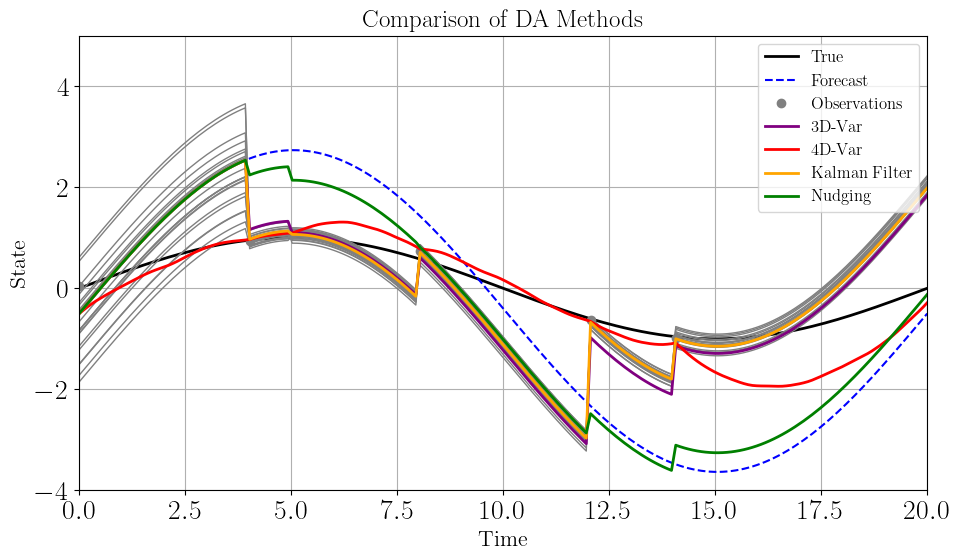

In [21]:
# === Comparison plot (assumes you already computed: nudging, kalman, enkf_mean, x3dvar, x_4dvar) ===

plt.figure(figsize=(10, 6))
plt.plot(t, true_signal, label="True", color="black", linewidth=2)
plt.plot(t, forecast, linestyle="--", label="Forecast", color="blue")
plt.plot(t[obs_indices], observations, 'o', label="Observations", color="gray", markersize=6)

# Methods (plot only those you have executed)
if 'enkf_mean' in globals():
    for n in range(n_ensemble):
        plt.plot(t, ensemble[n], color="gray", linewidth=1)
if 'x3dvar' in globals():
    plt.plot(t, x3dvar, label="3D-Var", color="purple", linewidth=2)
if 'x_4dvar' in globals():
    plt.plot(t, x_4dvar, label="4D-Var", color="red", linewidth=2)
if 'kalman' in globals():
    plt.plot(t, kalman, label="Kalman Filter", color="orange", linewidth=2)
if 'nudging' in globals():
    plt.plot(t, nudging, label="Nudging", color="green", linewidth=2)

plt.title("Comparison of DA Methods", fontsize=18)
plt.xlabel("Time", fontsize=16); plt.ylabel("State", fontsize=16)
plt.grid(True); plt.legend(fontsize=12, loc="upper right")
plt.xlim(0, 20); plt.ylim(-4, 5)
plt.tight_layout(); plt.show()
